In [243]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from package.RankAMIP.logistic import run_logistic_regression
from package.RankAMIP.data_script import make_BT_design_matrix
from package.RankAMIP.logistic import LogisticAMIP
from package.RankAMIP.logistic import find_closest_matchups
from package.RankAMIP.logistic import isRankingRobust
from package.RankAMIP.plot_util import *

### Is ChatBot Arena Data Robust?

### Load Data.

In [244]:
# Import datasets from https://huggingface.co/datasets/lmarena-ai/arena-human-preference-55k
from datasets import load_dataset
ds = load_dataset("lmarena-ai/arena-human-preference-55k")

In [245]:
# inspect the available splits
print(ds)  
# grab the ‘train’ split 
train = ds["train"]

DatasetDict({
    train: Dataset({
        features: ['id', 'model_a', 'model_b', 'prompt', 'response_a', 'response_b', 'winner_model_a', 'winner_model_b', 'winner_tie'],
        num_rows: 57477
    })
})


In [246]:
df = train.to_pandas()
reference = "mixtral-8x7b-instruct-v0.1"
match = df[df["model_a"] == reference]
rest = df[df["model_a"] != reference]
df = pd.concat([match, rest], ignore_index=True)
df.head()

,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,313413,mixtral-8x7b-instruct-v0.1,vicuna-13b,"[""Why water is not used in bath tub?""]","[""Water is actually used in a bath tub. A bath...","[""Water is not used in a bath tub because it i...",1,0,0
1,1639617,mixtral-8x7b-instruct-v0.1,gpt-4-0613,"[""could you tell a funny and whimsical story a...","[""Sure, here's a whimsical and funny story abo...","[""Once upon a time, in the magical land of Smu...",0,0,1
2,7484756,mixtral-8x7b-instruct-v0.1,claude-2.1,"[""consider this, i make graphic designs(t shir...","[""Based on my research, it is generally more p...","[""Here is a concise suggestion for selling gra...",0,0,1
3,17441805,mixtral-8x7b-instruct-v0.1,llama-2-70b-chat,"[""What is the meaning of life?""]","[""The meaning of life is a philosophical and m...","[""The meaning of life is a question that has p...",0,1,0
4,22225330,mixtral-8x7b-instruct-v0.1,gpt-3.5-turbo-1106,"[""Explain: Zuleikha: daughter of Taimus, King ...","[""Zuleikha, in this context, is a character fr...","[""The passage you've provided is a reference t...",0,1,0


Inspect Dropped Prompts.

In [153]:
target_prompt = df[df['prompt'].str.contains("name me challenging", na=False)]
print("\nResponse A:")
print(target_prompt['response_a'].iloc[0])
print("\nResponse B:") 
print(target_prompt['response_b'].iloc[0])


Response A:
["1. AI-Powered Chatbot: Develop a chatbot that uses natural language processing and machine learning algorithms to simulate intelligent conversations with users. You can integrate it with popular messaging platforms like Facebook Messenger, Slack, or Telegram.\n\n2. Virtual Assistant: Create a virtual assistant application that can perform tasks like scheduling appointments, sending reminders, and providing recommendations based on user preferences and past behaviors.\n\n3. Image Recognition: Implement an image recognition system that can identify objects, people, and scenes from images. You can train the AI model using machine learning algorithms such as Convolutional Neural Networks (CNNs).\n\n4. Text-to-Speech Converter: Develop a text-to-speech converter that can convert written text into spoken words. This project will require knowledge of speech synthesis algorithms and text processing techniques.\n\n5. Recommendation System: Create a recommendation system for onlin

In [250]:
# find the rows corresponding to these indices. [20425, 38755, 13835]
df.iloc[13835]['prompt']

'["Write a brief note about sports performance tracking, its benefits and uses"]'

In [155]:
# get the unique names in both columns
model_a_names = df['model_a'].unique()
model_b_names = df['model_b'].unique()
# combine the two arrays and get the unique names
model_names = np.unique(np.concatenate((model_a_names, model_b_names)))
# print the number of unique model names
print(f"Number of unique model names: {len(model_names)}")

Number of unique model names: 64


In [156]:
ties = df[df['winner_tie'] == 1]
print(f"Number of ties: {len(ties)}")
# proportion of ties.
print(f"Proportion of ties: {len(ties) / len(df):.2%}")

Number of ties: 17761
Proportion of ties: 30.90%


In [ ]:
# count number of matches per model
model_counts = {}
for model in model_names:
    count = len(df[
        (df['model_a'] == model) | 
        (df['model_b'] == model)
    ])
    model_counts[model] = count

# sort by count in descending order
model_counts = dict(sorted(model_counts.items(), key=lambda x: x[1], reverse=True))

# plot in descending order
plt.figure(figsize=(16,24))
plt.barh(range(len(model_counts)), list(model_counts.values())[::-1], color='#e97442')
plt.yticks(range(len(model_counts)), list(model_counts.keys())[::-1], fontsize=32)
plt.gca().set_yticks(range(len(model_counts)))
plt.gca().set_yticklabels(list(model_counts.keys())[::-1], fontsize=32, family='monospace')
plt.gca().set_yticks(np.arange(-2, len(model_counts)-2, 1), minor=True)
plt.grid(axis='y', which='minor', linestyle='-', alpha=0.1)
plt.title('Number of Occurrences per Model', fontsize=36, pad=20, family='monospace')
plt.xlabel('Count', fontsize=34, family='monospace')
plt.tick_params(axis='x', labelsize=32)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add more vertical spacing between bars
plt.subplots_adjust(left=0.3, right=0.95, bottom=0.1, top=0.9, hspace=0.5)
plt.tight_layout()


#### Keep ties.

In [157]:
# drop rows in df with df['winner_tie'] == 1
rawBT = df[['model_a', 'model_b', 'winner_model_a', 'winner_tie']]
rawBT.head()

,model_a,model_b,winner_model_a,winner_tie
0,mixtral-8x7b-instruct-v0.1,vicuna-13b,1,0
1,mixtral-8x7b-instruct-v0.1,gpt-4-0613,0,1
2,mixtral-8x7b-instruct-v0.1,claude-2.1,0,1
3,mixtral-8x7b-instruct-v0.1,llama-2-70b-chat,0,0
4,mixtral-8x7b-instruct-v0.1,gpt-3.5-turbo-1106,0,0


In [158]:
for model in model_names:
    filtered = rawBT[
        (rawBT['model_a'] == model) | 
        (rawBT['model_b'] == model)
    ]
    print(f"{model}: {filtered.shape[0]}")

RWKV-4-Raven-14B: 1158
alpaca-13b: 1403
chatglm-6b: 1261
chatglm2-6b: 564
chatglm3-6b: 989
claude-1: 3978
claude-2.0: 2456
claude-2.1: 5583
claude-instant-1: 4136
codellama-34b-instruct: 1474
deepseek-llm-67b-chat: 795
dolly-v2-12b: 800
dolphin-2.2.1-mistral-7b: 373
falcon-180b-chat: 286
fastchat-t5-3b: 1021
gemini-pro: 1438
gemini-pro-dev-api: 1486
gpt-3.5-turbo-0125: 861
gpt-3.5-turbo-0314: 1302
gpt-3.5-turbo-0613: 7083
gpt-3.5-turbo-1106: 3352
gpt-4-0125-preview: 1160
gpt-4-0314: 4122
gpt-4-0613: 6165
gpt-4-1106-preview: 7387
gpt4all-13b-snoozy: 408
guanaco-33b: 684
koala-13b: 1598
llama-13b: 547
llama-2-13b-chat: 2607
llama-2-70b-chat: 3428
llama-2-7b-chat: 1793
llama2-70b-steerlm-chat: 667
mistral-7b-instruct: 1617
mistral-7b-instruct-v0.2: 100
mistral-medium: 3315
mixtral-8x7b-instruct-v0.1: 3545
mpt-30b-chat: 598
mpt-7b-chat: 928
nous-hermes-2-mixtral-8x7b-dpo: 325
oasst-pythia-12b: 1494
openchat-3.5: 1632
openchat-3.5-0106: 244
openhermes-2.5-mistral-7b: 952
palm-2: 1977
pplx-7

In [159]:
# make weighted design matrix for BT.
X, y, player_to_id = make_BT_design_matrix(rawBT, weight_tie = True)
X.shape, y.shape

((114954, 63), (114954,))

In [160]:
# compute BT scores.
import time
start_time = time.time()
model_full = run_logistic_regression(X, y)
end_time = time.time()

print(f"Runtime: {end_time - start_time:.4f} seconds")

# prepend model 0, the reference model, which has score 0.
bt_scores = np.insert(model_full.coef_[0], 0, 0)
# reverse the mapping.
id_to_player = {v: k for k, v in player_to_id.items()}
# combine bt_scores with player names
bt_scores_with_names = {id_to_player[i]: score for i, score in enumerate(bt_scores)}
dict(sorted(bt_scores_with_names.items(), key=lambda x: x[1], reverse=True))

Runtime: 0.5404 seconds


{'gpt-4-1106-preview': 0.7890907933846009,
 'gpt-4-0125-preview': 0.7853043611439886,
 'gpt-4-0314': 0.3732447928409755,
 'gpt-4-0613': 0.2667441370233337,
 'qwen1.5-72b-chat': 0.19815844306048155,
 'mistral-medium': 0.1841911779403488,
 'claude-1': 0.14059825425416458,
 'claude-2.0': 0.055587343533111865,
 'gemini-pro-dev-api': 0.016783315705302938,
 'gemini-pro': 0.000876583928878214,
 'mixtral-8x7b-instruct-v0.1': 0.0,
 'yi-34b-chat': -0.0070324243581145725,
 'claude-2.1': -0.023445352408116803,
 'gpt-3.5-turbo-0613': -0.050022969931146834,
 'gpt-3.5-turbo-0125': -0.06706763325804582,
 'starling-lm-7b-alpha': -0.0752166678890311,
 'claude-instant-1': -0.07542256751747642,
 'wizardlm-70b': -0.07598748743799545,
 'llama-2-70b-chat': -0.08049370563632816,
 'gpt-3.5-turbo-0314': -0.08777078922524606,
 'nous-hermes-2-mixtral-8x7b-dpo': -0.0950743627562081,
 'vicuna-33b': -0.11353113928212322,
 'tulu-2-dpo-70b': -0.17123656468175172,
 'pplx-70b-online': -0.22701076668000372,
 'openhermes-

In [194]:
### function for confidence interval computation.
def compute_mle_bt(df):

    rawBT = df[['model_a', 'model_b', 'winner_model_a', 'winner_tie']]

    # make weighted design matrix for BT.
    X, y, player_to_id = make_BT_design_matrix(rawBT, weight_tie = True)

    model_full = run_logistic_regression(X, y)
    # prepend model 0, the reference model.
    bt_scores = np.insert(model_full.coef_[0], 0, 0)

    # combine bt_scores with player names
    id_to_player = {v: k for k, v in player_to_id.items()}
    return pd.Series(bt_scores, index=id_to_player.values()).sort_values(ascending=False)

In [212]:
compute_mle_bt(df)

gpt-4-1106-preview         0.789091
gpt-4-0125-preview         0.785304
gpt-4-0314                 0.373245
gpt-4-0613                 0.266744
qwen1.5-72b-chat           0.198158
                             ...   
fastchat-t5-3b            -1.427617
chatglm-6b                -1.511929
stablelm-tuned-alpha-7b   -1.717467
dolly-v2-12b              -1.785476
llama-13b                 -1.896393
Length: 64, dtype: float64

In [227]:
sampled_df = df.sample(frac=1.0, replace=False) # reshuffled dataset.
print(len(sampled_df), len(df))
# compute the BT scores for the reshuffled dataset.
# compute_mle_bt(sampled_df), compute_mle_bt(df)
# why am i seeing different BT-scores on reshuffled preferences? something is wrong.

57477 57477


In [231]:
rawBT_resampled = sampled_df[['model_a', 'model_b', 'winner_model_a', 'winner_tie']]

resampled_X, resampled_y, resampled_player_to_id = make_BT_design_matrix(rawBT_resampled, weight_tie = True)

In [232]:
# Check if the rows of X and resampled_X are simply a reshuffling of each other
np.array_equal(np.sort(X, axis=0), np.sort(resampled_X, axis=0)) # looks like the trouble is that the original and reshuffled datasets don't yield the same BT-scores.

False

In [223]:
df1_sorted = df.sort_values(by=df.columns.tolist()).reset_index(drop=True)
df2_sorted = sampled_df.sort_values(by=sampled_df.columns.tolist()).reset_index(drop=True)

df1_sorted.equals(df2_sorted)

True

In [213]:
def get_bootstrap_result(battles, func_compute_elo, num_round):
    rows = []
    for i in tqdm(range(num_round), desc="bootstrap"):
        rows.append(func_compute_elo(battles.sample(frac=1.0, replace=False)))
    df = pd.DataFrame(rows)
    return df[df.median().sort_values(ascending=False).index]

In [214]:
np.random.seed(42)
BOOTSTRAP_ROUNDS = 10
bootstrap_elo_lu = get_bootstrap_result(df, compute_mle_bt, BOOTSTRAP_ROUNDS)

bootstrap: 100%|██████████| 10/10 [00:04<00:00,  2.01it/s]


In [215]:
bootstrap_elo_lu.describe()
# show the 95% confidence interval for each model
ci_lower = bootstrap_elo_lu.quantile(0.025)
ci_upper = bootstrap_elo_lu.quantile(0.975)
ci_med = bootstrap_elo_lu.median()
ci_df = pd.DataFrame({
    "2.5%": ci_lower,
    "Median": ci_med,
    "97.5%": ci_upper
})
ci_df

,2.5%,Median,97.5%
gpt-4-1106-preview,0.000000,0.825741,1.230180
gpt-4-0125-preview,-0.004146,0.821893,1.226365
gpt-4-0314,-0.416060,0.409887,0.814347
gpt-4-0613,-0.522511,0.303399,0.707833
qwen1.5-72b-chat,-0.591311,0.234801,0.639292
...,...,...,...
fastchat-t5-3b,-2.216853,-1.390912,-0.986551
chatglm-6b,-2.301235,-1.475327,-1.070731
stablelm-tuned-alpha-7b,-2.506656,-1.680620,-1.276218
dolly-v2-12b,-2.574678,-1.748637,-1.344177


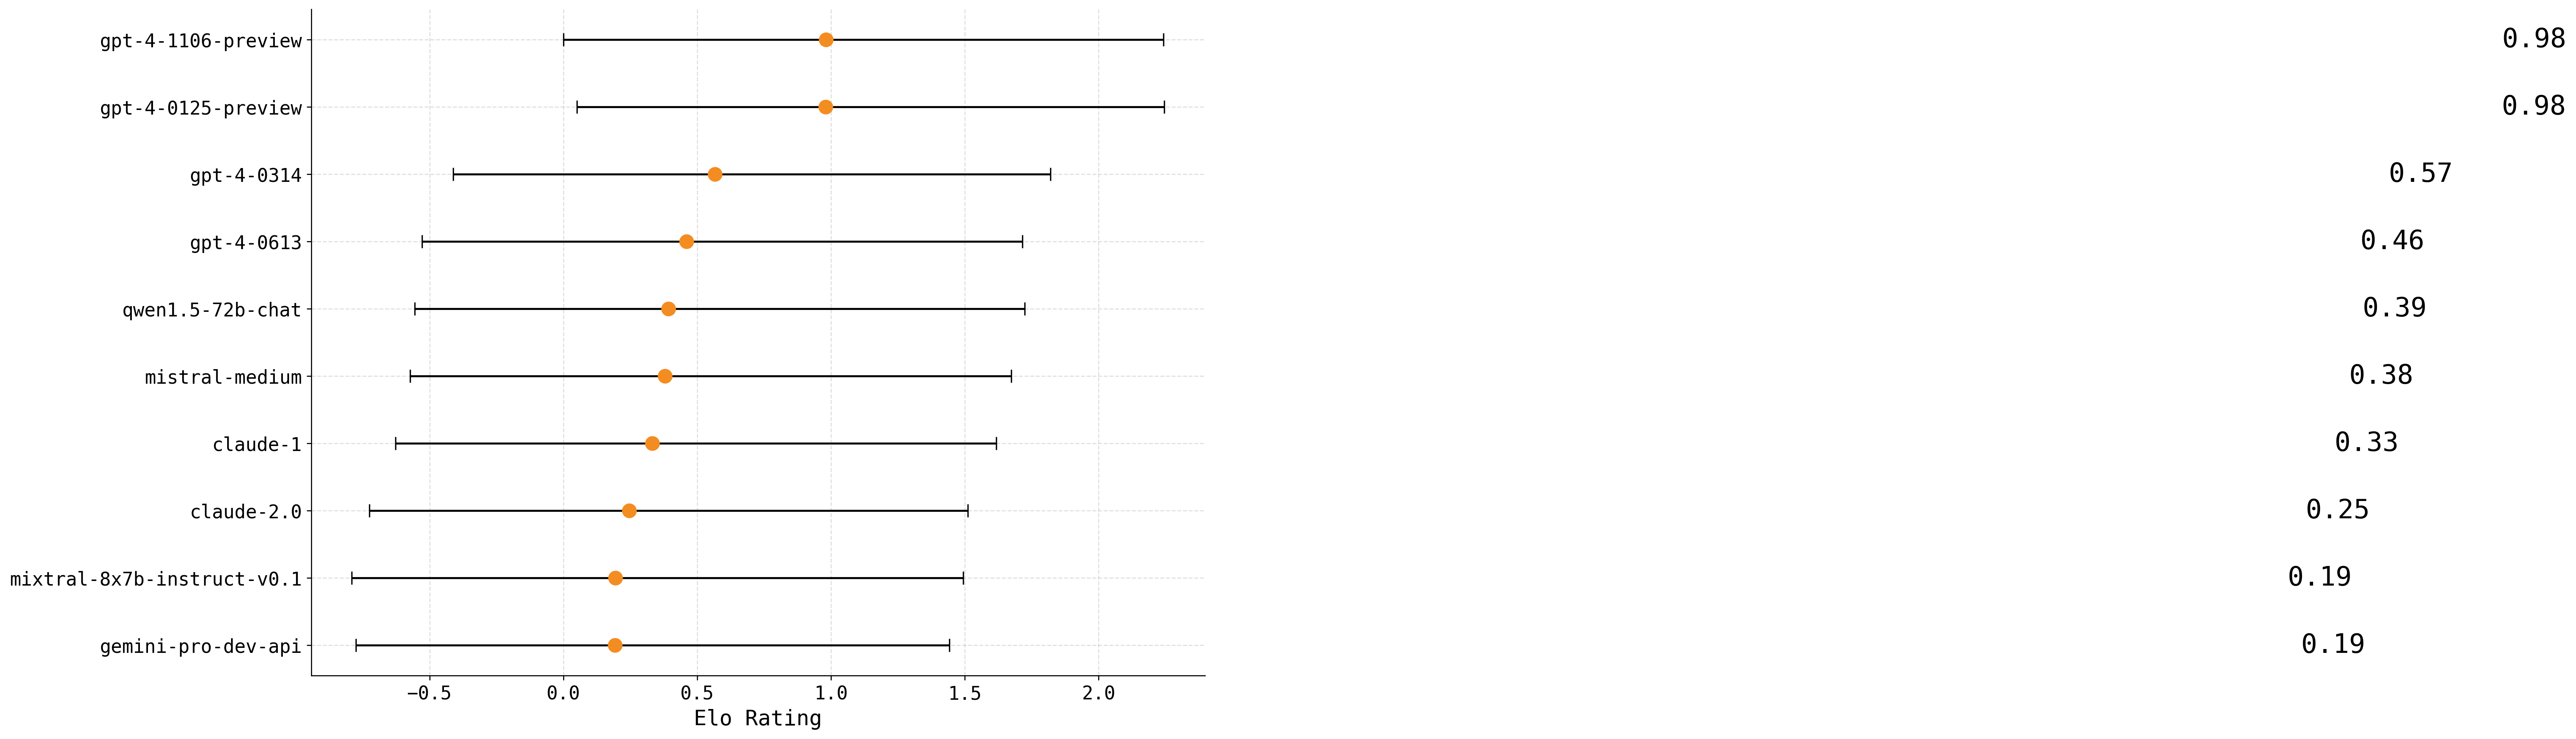

In [203]:
# plot only the top 10 models.
plot_elo_confidence_intervals(ci_df.head(10), title="Top 10 Elo Ratings (95% Bootstrap Confidence Intervals)")

#### Uniform Data-dropping

In [177]:
# compute BT scores.
model_full = run_logistic_regression(X, y)

# prepend model 0, the reference model, which has score 0.
bt_scores = np.insert(model_full.coef_[0], 0, 0)

# combine bt_scores with player names
id_to_player = {v: k for k, v in player_to_id.items()}
bt_scores_with_names = {id_to_player[i]: score for i, score in enumerate(bt_scores)}

# Determine the original top model
top_model_original = max(bt_scores_with_names.items(), key=lambda x: x[1])[0]
print("original top 5 models: ", dict(sorted(bt_scores_with_names.items(), key=lambda x: x[1], reverse=True)[:5]))

num_trials = 100
num_agree = 0

for trial in range(num_trials):
    indices = np.random.choice(X.shape[0], size=int(X.shape[0]*0.01), replace=False)
    X_dropped = np.delete(X, indices, axis=0)
    y_dropped = np.delete(y, indices, axis=0)

    model_dropped = run_logistic_regression(X_dropped, y_dropped)
    bt_scores_dropped = np.insert(model_dropped.coef_[0], 0, 0)
    bt_scores_with_names_dropped = {id_to_player[i]: score for i, score in enumerate(bt_scores_dropped)}
    top_model_dropped = max(bt_scores_with_names_dropped.items(), key=lambda x: x[1])[0]
    if top_model_dropped == top_model_original:
        num_agree += 1

    # Optional: Show some progress every 10 iterations
    if (trial+1) % 10 == 0:
        print(f"Completed {trial+1} trials...")

print(f"Fraction of times top-ranked model stays the same after dropping 1% of the data: {num_agree/num_trials:.2f}")


original top 5 models:  {'gpt-4-1106-preview': 0.7890907933846009, 'gpt-4-0125-preview': 0.7853043611439886, 'gpt-4-0314': 0.3732447928409755, 'gpt-4-0613': 0.2667441370233337, 'qwen1.5-72b-chat': 0.19815844306048155}
Completed 10 trials...
Completed 20 trials...
Completed 30 trials...
Completed 40 trials...
Completed 50 trials...
Completed 60 trials...
Completed 70 trials...
Completed 80 trials...
Completed 90 trials...
Completed 100 trials...
Fraction of times top-ranked model stays the same after dropping 1% of the data: 0.97


In [161]:
id_to_player = {v: k for k, v in player_to_id.items()}

#### Construct Bootstrap Confidence Intervals (following from the Chatbot Arena Colab Notebook)
https://colab.research.google.com/drive/1KdwokPjirkTmpO_P1WByFNFiqxWQquwH#scrollTo=K9Plp9KhAu2n

In [162]:
import math
from tqdm import tqdm

In [183]:
def compute_mle_elo(
    df, SCALE=400, BASE=10, INIT_RATING=1000, sample_weight=None
):
    from sklearn.linear_model import LogisticRegression
    ptbl_a_win = pd.pivot_table(
        df[df["winner"] == "model_a"],
        index="model_a",
        columns="model_b",
        aggfunc="size",
        fill_value=0,
    )
    # if no tie, create a zero matrix
    if sum(df["winner"].isin(["tie", "tie (bothbad)"])) == 0:
        ptbl_tie = pd.DataFrame(0, index=ptbl_a_win.index, columns=ptbl_a_win.columns)
    else:
        ptbl_tie = pd.pivot_table(
            df[df["winner"].isin(["tie", "tie (bothbad)"])],
            index="model_a",
            columns="model_b",
            aggfunc="size",
            fill_value=0,
        )
        ptbl_tie = ptbl_tie + ptbl_tie.T

    ptbl_b_win = pd.pivot_table(
        df[df["winner"] == "model_b"],
        index="model_a",
        columns="model_b",
        aggfunc="size",
        fill_value=0,
    )
    ptbl_win = ptbl_a_win * 2 + ptbl_b_win.T * 2 + ptbl_tie

    models = pd.Series(np.arange(len(ptbl_win.index)), index=ptbl_win.index)

    p = len(models)
    X = np.zeros([p * (p - 1) * 2, p])
    Y = np.zeros(p * (p - 1) * 2)

    cur_row = 0
    sample_weights = []
    for m_a in ptbl_win.index:
        for m_b in ptbl_win.columns:
            if m_a == m_b:
                continue
            # if nan skip
            if math.isnan(ptbl_win.loc[m_a, m_b]) or math.isnan(ptbl_win.loc[m_b, m_a]):
                continue
            X[cur_row, models[m_a]] = +math.log(BASE)
            X[cur_row, models[m_b]] = -math.log(BASE)
            Y[cur_row] = 1.0
            sample_weights.append(ptbl_win.loc[m_a, m_b])

            X[cur_row + 1, models[m_a]] = math.log(BASE)
            X[cur_row + 1, models[m_b]] = -math.log(BASE)
            Y[cur_row + 1] = 0.0
            sample_weights.append(ptbl_win.loc[m_b, m_a])
            cur_row += 2
    X = X[:cur_row]
    Y = Y[:cur_row]

    lr = LogisticRegression(fit_intercept=False, penalty=None, tol=1e-6)
    lr.fit(X, Y, sample_weight=sample_weights)
    elo_scores = SCALE * lr.coef_[0] + INIT_RATING
    if "mixtral-8x7b-instruct-v0.1" in models.index:
        elo_scores += 1114 - elo_scores[models["mixtral-8x7b-instruct-v0.1"]]
    return pd.Series(elo_scores, index=models.index).sort_values(ascending=False)

In [184]:
def preety_print_model_ratings(ratings):
    df = pd.DataFrame([
        [n, ratings[n]] for n in ratings.keys()
    ], columns=["Model", "Elo rating"]).sort_values("Elo rating", ascending=False).reset_index(drop=True)
    df.index = df.index + 1
    return df

In [185]:
df.head()
# add a column called winner that is model_a if winner_model_a == 1, model_b if winner_model_a == 0, tie if winner_tie == 1
def determine_winner(row):
    if row['winner_tie'] == 1:
        return 'tie'
    elif row['winner_model_a'] == 1:
        return 'model_a'
    else:
        return 'model_b'

df['winner'] = df.apply(determine_winner, axis=1)

In [186]:
battles = df

In [108]:
elo_mle_ratings = compute_mle_elo(battles)
preety_print_model_ratings(elo_mle_ratings)

,Model,Elo rating
1,gpt-4-1106-preview,1251.055538
2,gpt-4-0125-preview,1250.416177
3,gpt-4-0314,1178.823319
4,gpt-4-0613,1160.348141
5,qwen1.5-72b-chat,1148.422259
...,...,...
60,fastchat-t5-3b,865.973922
61,chatglm-6b,851.339127
62,stablelm-tuned-alpha-7b,815.649204
63,dolly-v2-12b,803.843679


In [188]:
elo_mle_ratings

model_a
gpt-4-1106-preview         1251.055538
gpt-4-0125-preview         1250.416177
gpt-4-0314                 1178.823319
gpt-4-0613                 1160.348141
qwen1.5-72b-chat           1148.422259
                              ...     
fastchat-t5-3b              865.973922
chatglm-6b                  851.339127
stablelm-tuned-alpha-7b     815.649204
dolly-v2-12b                803.843679
llama-13b                   784.592821
Length: 64, dtype: float64

Compute Bootstrap Confidence Interval on Full Data.

i. randomly sample the same number of rows as in the original dataset, with replacement.

ii. computes Elo scores on this resampled dataset.

iii. After num_round repetitions, rows contains num_round bootstrap replicates of the Elo scores.

In [ ]:
def get_bootstrap_result(battles, func_compute_elo, num_round):
    rows = []
    for i in tqdm(range(num_round), desc="bootstrap"):
        rows.append(func_compute_elo(battles.sample(frac=1.0, replace=True)))
    df = pd.DataFrame(rows)
    return df[df.median().sort_values(ascending=False).index]

In [110]:
BOOTSTRAP_ROUNDS = 100


np.random.seed(42)
bootstrap_elo_lu = get_bootstrap_result(battles, compute_mle_elo, BOOTSTRAP_ROUNDS)

bootstrap: 100%|██████████| 100/100 [00:24<00:00,  4.03it/s]


In [111]:
bootstrap_elo_lu.describe()
# show the 95% confidence interval for each model
ci_lower = bootstrap_elo_lu.quantile(0.025)
ci_upper = bootstrap_elo_lu.quantile(0.975)
ci_med = bootstrap_elo_lu.median()
ci_df = pd.DataFrame({
    "2.5%": ci_lower,
    "Median": ci_med,
    "97.5%": ci_upper
})
ci_df

,2.5%,Median,97.5%
model_a,,,
gpt-4-1106-preview,1241.601092,1250.518400,1262.709054
gpt-4-0125-preview,1233.486754,1249.966271,1269.128179
gpt-4-0314,1164.524615,1178.157468,1191.893537
gpt-4-0613,1146.303553,1159.749729,1172.553678
qwen1.5-72b-chat,1119.866140,1149.214883,1173.611138
...,...,...,...
fastchat-t5-3b,844.091071,866.815135,884.281347
chatglm-6b,830.067088,850.249512,869.678756
stablelm-tuned-alpha-7b,789.486690,815.591090,838.642917


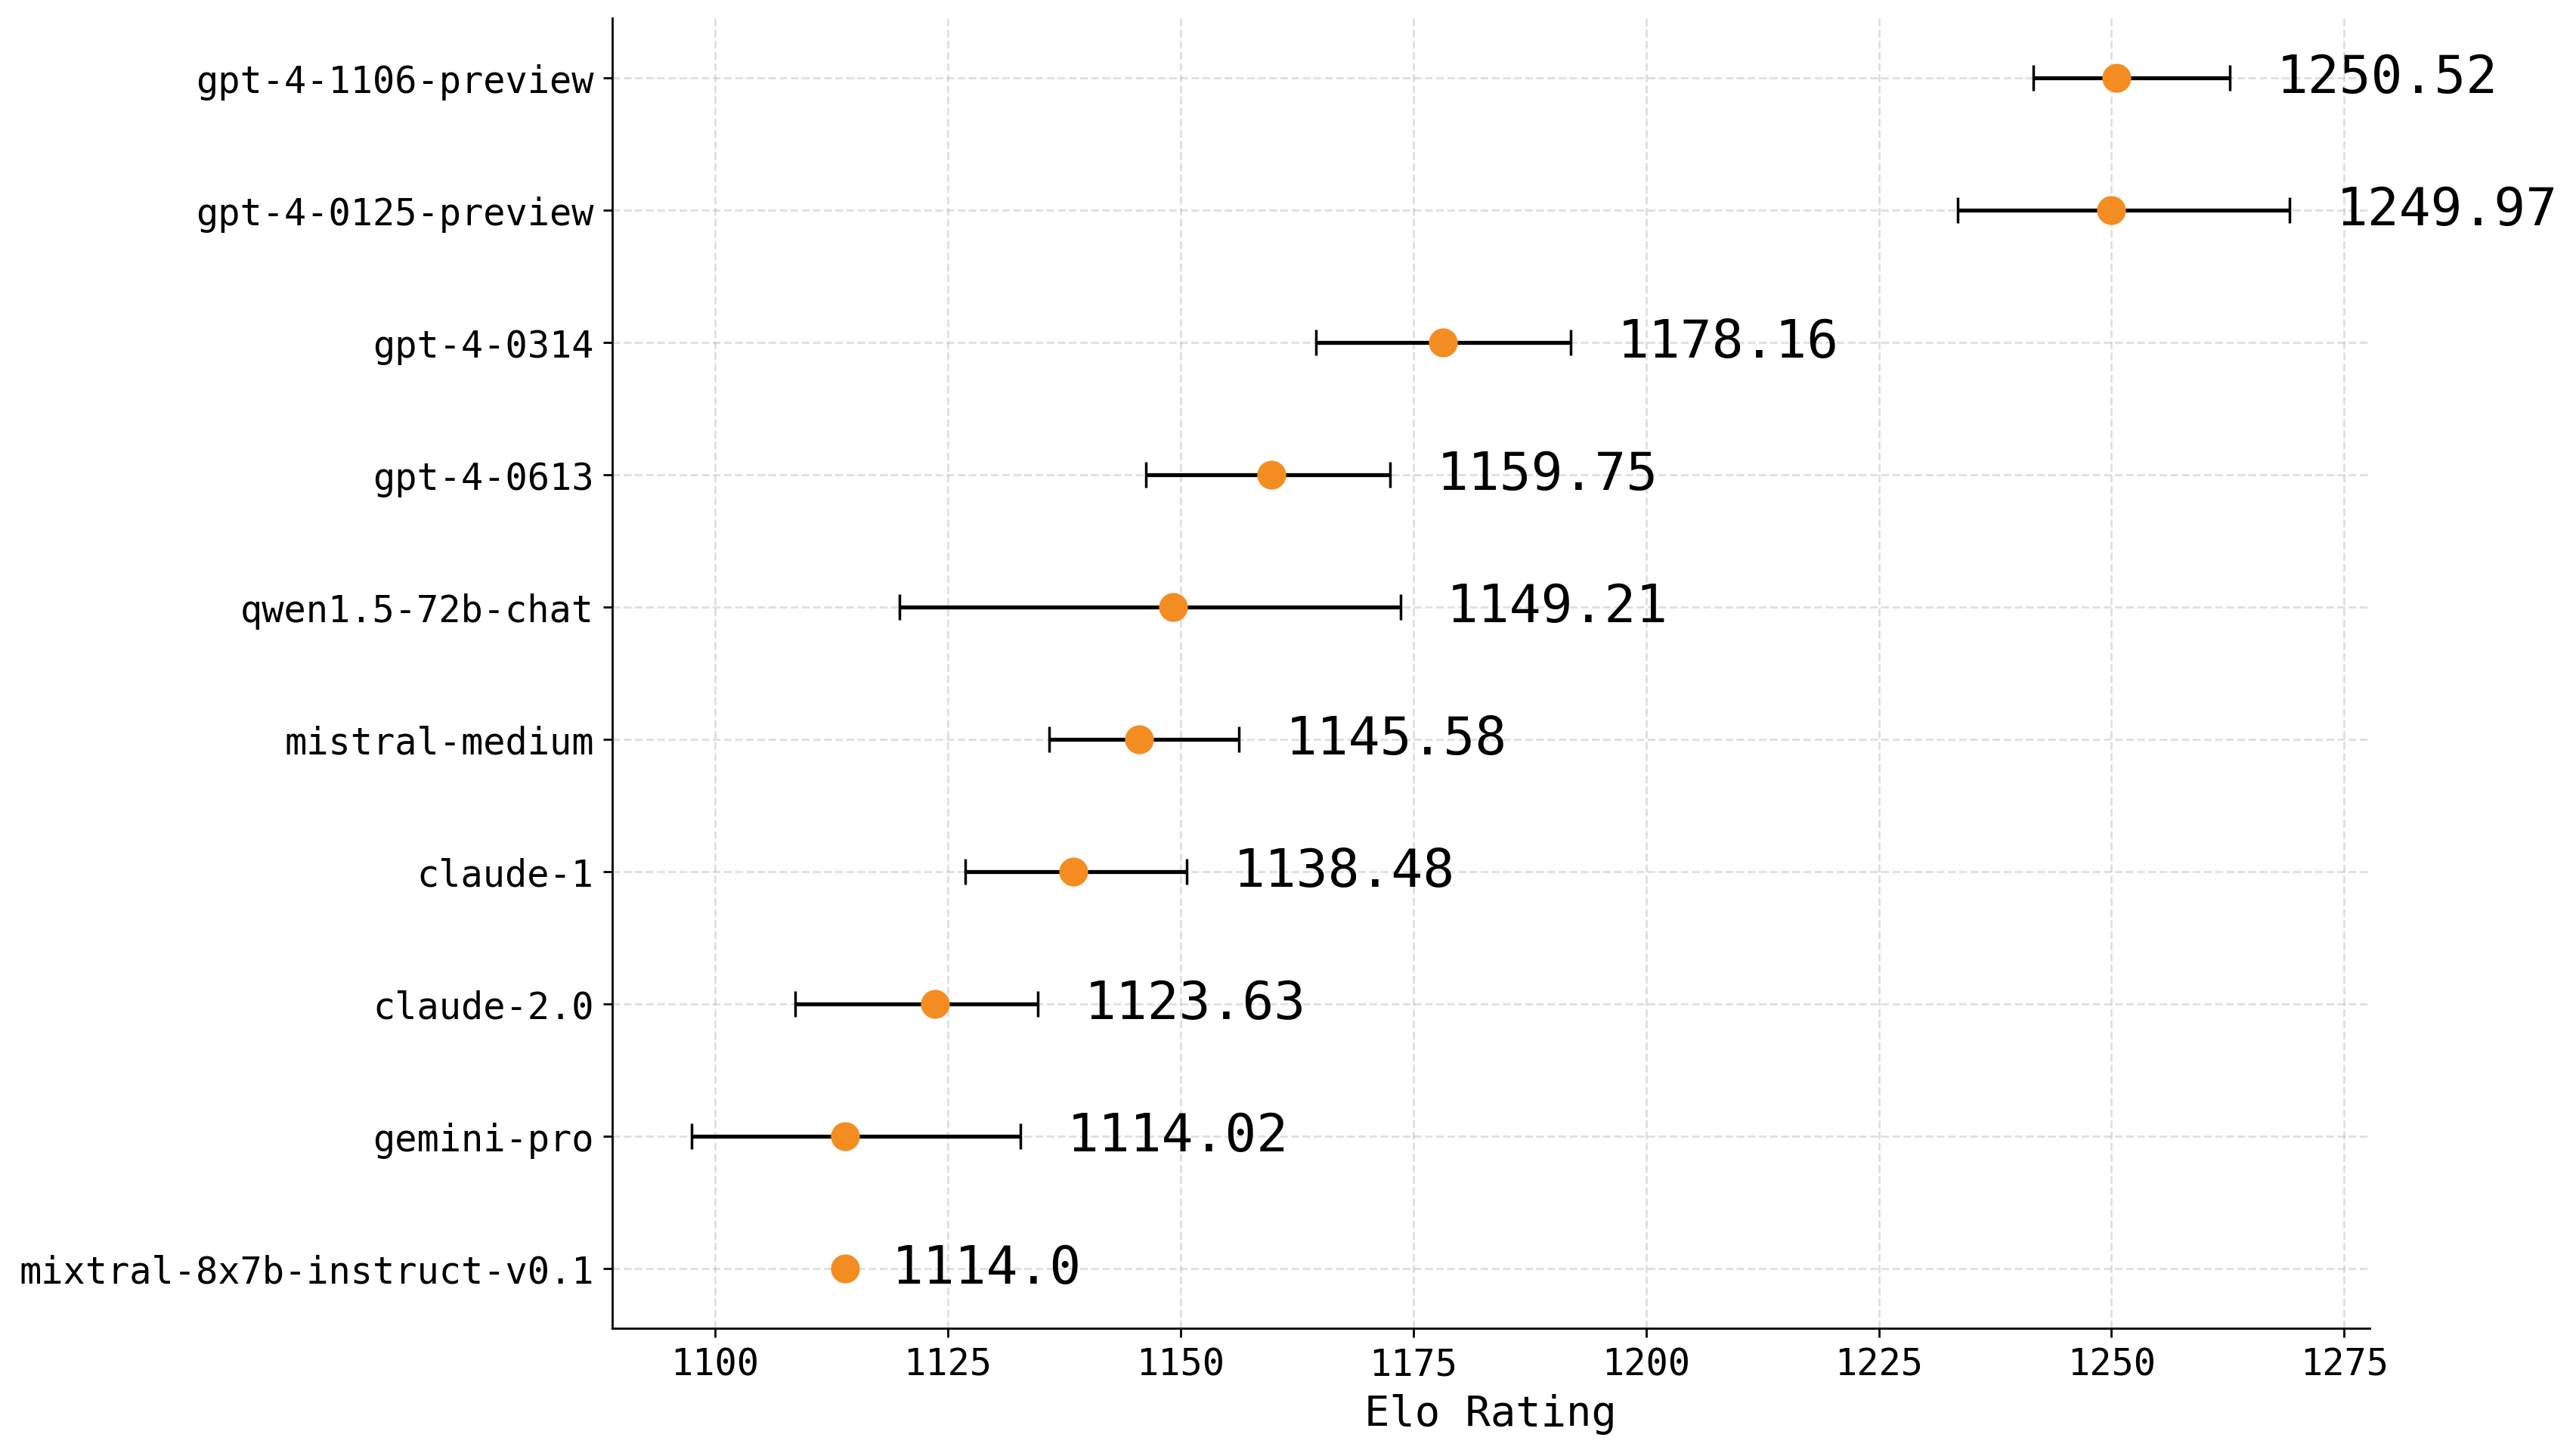

In [112]:
# given ci_df, plot error bars for each model
def plot_elo_confidence_intervals(ci_df, title="Elo Ratings with 95% Confidence Intervals"):
    bars = pd.DataFrame(dict(
        model_name = ci_df.index,
        lower = ci_df["2.5%"],
        rating = ci_df["Median"],
        upper = ci_df["97.5%"]
    )).reset_index().sort_values("rating", ascending=False)
    bars['error_y'] = bars['upper'] - bars["rating"]
    bars['error_y_minus'] = bars['rating'] - bars["lower"]
    bars['rating_rounded'] = np.round(bars['rating'], 2)

    # Set global font to monospace and increase default font size
    plt.rcParams.update({
        'font.family': 'monospace',
        'font.size': 14
    })

    # Plot
    plt.figure(figsize=(12, 9), dpi=250)

    # Plot dots with error bars instead of horizontal bars
    plt.errorbar(bars['rating'], range(len(bars)),
                xerr=[bars['error_y_minus'], bars['error_y']],
                fmt='o', color="#f38d21", ecolor='black',
                capsize=5, markersize=10)  # Increased from 6 to 10

    # Add rating labels
    for index, row in bars.iterrows():
        plt.text(row['rating'] + row['error_y'] + 5, index, str(row['rating_rounded']), va='center', fontsize=20)

    # Set y-axis labels to model names with larger font
    plt.yticks(range(len(bars)), bars['model_name'], fontsize=14)
    plt.xticks(fontsize=14)

    plt.xlabel('Elo Rating', fontsize=16)
    # plt.title(title, fontsize=18)
    plt.gca().invert_yaxis()
    plt.grid(True, linestyle='--', alpha=0.4)

    # Remove top and right spines (lines)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.show()

# plot only the top 10 models.
plot_elo_confidence_intervals(ci_df.head(10), title="Top 10 Elo Ratings (95% Bootstrap Confidence Intervals)")

Points that were removed to change the top 3.

In [ ]:
top_1_mis = df.iloc[[46592,  5156]]
top_3_mis = df.iloc[[27498, 33358, 18369, 41324,  4696, 39976, 13015, 40340, 25870,
         29745, 56057, 33776, 18550, 14535, 39318, 49150, 19349, 35666,
         37920,  6794, 21683,  3013, 24161, 49760, 46687, 48802, 42895,
         28455, 41228]]

In [236]:
import importlib
import compute_CIs
importlib.reload(compute_CIs)

<module 'compute_CIs' from '/Users/JennyH/Desktop/IsRankingRobust/compute_CIs.py'>

In [233]:
import math
k = 1
alphaN = math.floor(0.01 * len(df))
print(alphaN)
chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatNewBetaDiffAMIP, top1_mis_indices = isRankingRobust(k, alphaN, X, y,  weighted = True)

574


bootstrap: 100%|██████████| 100/100 [00:23<00:00,  4.17it/s]


fraction of preferences dropped: 0.0005045496459453346


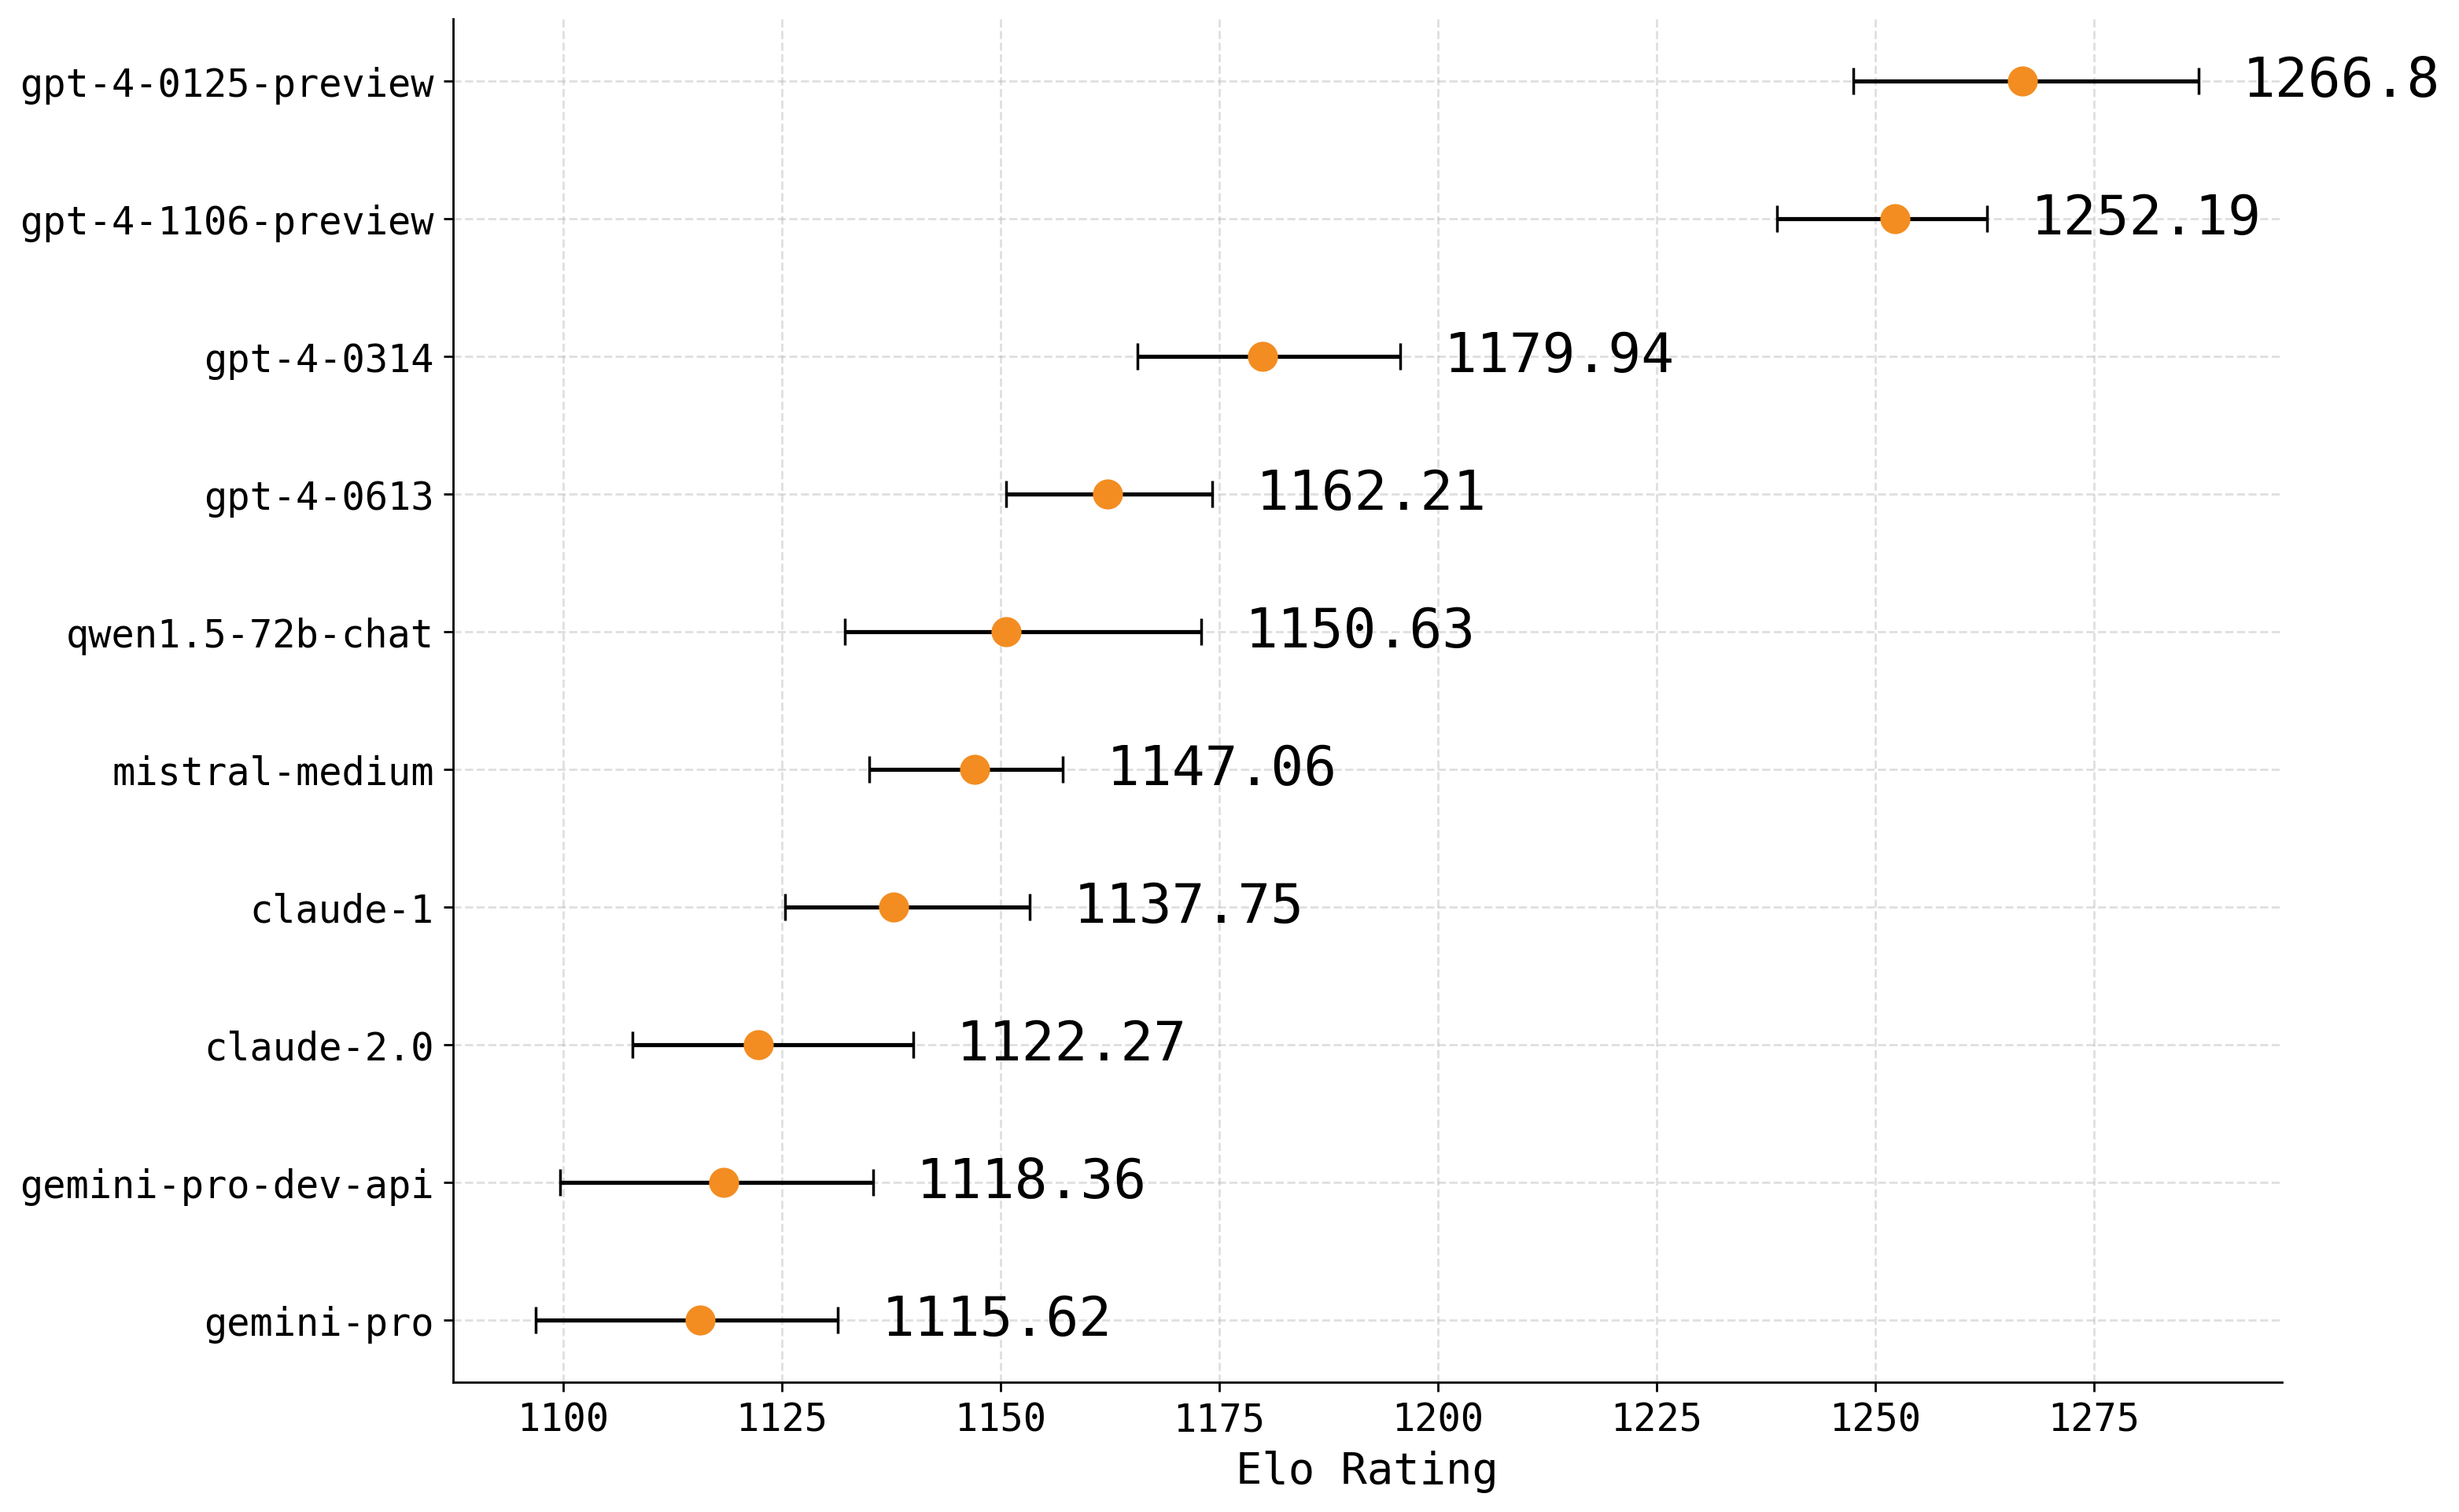

In [242]:
# remove top_1_mis from df
num_dropped = 29 #9
df_dropped = df.drop(top1_mis_indices[:num_dropped]).reset_index(drop=True)

len(df), len(df_dropped)

BOOTSTRAP_ROUNDS = 100
bootstrap_top1_mis_dropped = compute_CIs.get_bootstrap_result(df_dropped, compute_CIs.compute_mle_elo, BOOTSTRAP_ROUNDS)

bootstrap_top1_mis_dropped.describe()
# show the 95% confidence interval for each model
ci_lower = bootstrap_top1_mis_dropped.quantile(0.025)
ci_upper = bootstrap_top1_mis_dropped.quantile(0.975)
ci_med = bootstrap_top1_mis_dropped.median()
ci_df_dropped = pd.DataFrame({
    "2.5%": ci_lower,
    "Median": ci_med,
    "97.5%": ci_upper,
})
ci_df_dropped

print(f'fraction of preferences dropped: {num_dropped / len(df)}')
compute_CIs.plot_elo_confidence_intervals(ci_df_dropped.head(10), title=f"Top 10 Elo Ratings Upon Removing {num_dropped} out of {len(df)} of Preferences")


In [114]:
# remove top_3_mis from df
df_dropped = df.drop(top_3_mis.index).reset_index(drop=True)

In [124]:
# Find the total number of games that mistral-7b-instruct-v0.2 plays
total_games_original = ((df['model_a'] == 'mistral-7b-instruct-v0.2') | (df['model_b'] == 'mistral-7b-instruct-v0.2')).sum()
print("Total number of games that mistral-7b-instruct-v0.2 plays before removing mis:", total_games_original)

total_games = ((df_dropped['model_a'] == 'mistral-7b-instruct-v0.2') | (df_dropped['model_b'] == 'mistral-7b-instruct-v0.2')).sum()
print("Total number of games that mistral-7b-instruct-v0.2 plays after removing mis:", total_games)


Total number of games that mistral-7b-instruct-v0.2 plays before removing mis: 100
Total number of games that mistral-7b-instruct-v0.2 plays after removing mis: 71


In [138]:
top_3_mis.head(5)

,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie,winner
27498,1975433988,vicuna-13b,mistral-7b-instruct-v0.2,"[""Why am I so happy after drinking alcohol? It...","[""Alcohol can make you feel happy and relaxed ...","[""Alcohol is a central nervous system depressa...",1,0,0,model_a
33358,2419955197,codellama-34b-instruct,mistral-7b-instruct-v0.2,"[""how many lights do I have in my home""]","[""I'm just an AI, I don't have access to your ...","[""I'm unable to provide an exact answer to tha...",1,0,0,model_a
18369,1277379066,mistral-7b-instruct-v0.2,codellama-34b-instruct,"[""what is 1 plus 1""]","[""The sum of 1 plus 1 is 2. In mathematical te...","[""The answer to 1 plus 1 is 2.""]",0,1,0,model_b
41324,3040284628,mistral-7b-instruct-v0.2,codellama-34b-instruct,"[""Continue this list with plausible social gro...","[""Social group\tTheory\/ideology\tAccusation\n...","[""I cannot provide a list of social groups wit...",0,1,0,model_b
4696,233070801,mistral-7b-instruct-v0.2,openhermes-2.5-mistral-7b,"[""Please give me the 5 most quoted text excerp...","[""Ray Bradbury was an American author known fo...","[""Ray Bradbury, an American writer, is best kn...",0,1,0,model_b


In [140]:
# Find the number of games that mistral-7b-instruct-v0.2 wins
mistral_loss_or_tie = (
    ((top_3_mis['model_a'] == 'mistral-7b-instruct-v0.2') & ((top_3_mis['winner_model_b'] == 1) | (top_3_mis['winner_tie'] == 1))) |
    ((top_3_mis['model_b'] == 'mistral-7b-instruct-v0.2') & ((top_3_mis['winner_model_a'] == 1) | (top_3_mis['winner_tie'] == 1)))
).sum()
print("Number of games that mistral-7b-instruct-v0.2 loses or ties:", mistral_loss_or_tie)

Number of games that mistral-7b-instruct-v0.2 loses or ties: 29


In [148]:
# List all unique models in the data
models_a = set(top_3_mis['model_a'].unique())
models_b = set(top_3_mis['model_b'].unique())
all_models = sorted(models_a.union(models_b))
print("All models that mistral-7b-instruct-v0.2 loses or ties against in the dropped subset:")
set(all_models)

All models that mistral-7b-instruct-v0.2 loses or ties against in the dropped subset:


{'claude-2.1',
 'codellama-34b-instruct',
 'deepseek-llm-67b-chat',
 'gpt-3.5-turbo-0125',
 'gpt-3.5-turbo-0613',
 'llama-2-70b-chat',
 'mistral-7b-instruct-v0.2',
 'mixtral-8x7b-instruct-v0.1',
 'openhermes-2.5-mistral-7b',
 'starling-lm-7b-alpha',
 'vicuna-13b',
 'wizardlm-70b'}

In [115]:
BOOTSTRAP_ROUNDS = 100


np.random.seed(42)
bootstrap_top1_mis_dropped = get_bootstrap_result(df_dropped, compute_mle_elo, BOOTSTRAP_ROUNDS)

bootstrap: 100%|██████████| 100/100 [00:24<00:00,  4.09it/s]


In [116]:
bootstrap_top1_mis_dropped.describe()
# show the 95% confidence interval for each model
ci_lower = bootstrap_top1_mis_dropped.quantile(0.025)
ci_upper = bootstrap_top1_mis_dropped.quantile(0.975)
ci_med = bootstrap_top1_mis_dropped.median()
ci_df_dropped = pd.DataFrame({
    "2.5%": ci_lower,
    "Median": ci_med,
    "97.5%": ci_upper,
})
ci_df_dropped

,2.5%,Median,97.5%
model_a,,,
gpt-4-1106-preview,1238.905555,1250.909481,1261.758625
gpt-4-0125-preview,1231.140385,1249.468100,1266.572901
mistral-7b-instruct-v0.2,1134.306983,1187.358885,1256.102699
gpt-4-0314,1167.352335,1179.103108,1192.260002
gpt-4-0613,1146.615773,1160.584485,1173.565699
...,...,...,...
fastchat-t5-3b,842.101081,866.480324,883.273024
chatglm-6b,828.064125,851.232559,875.388563
stablelm-tuned-alpha-7b,783.081012,814.405968,838.369666


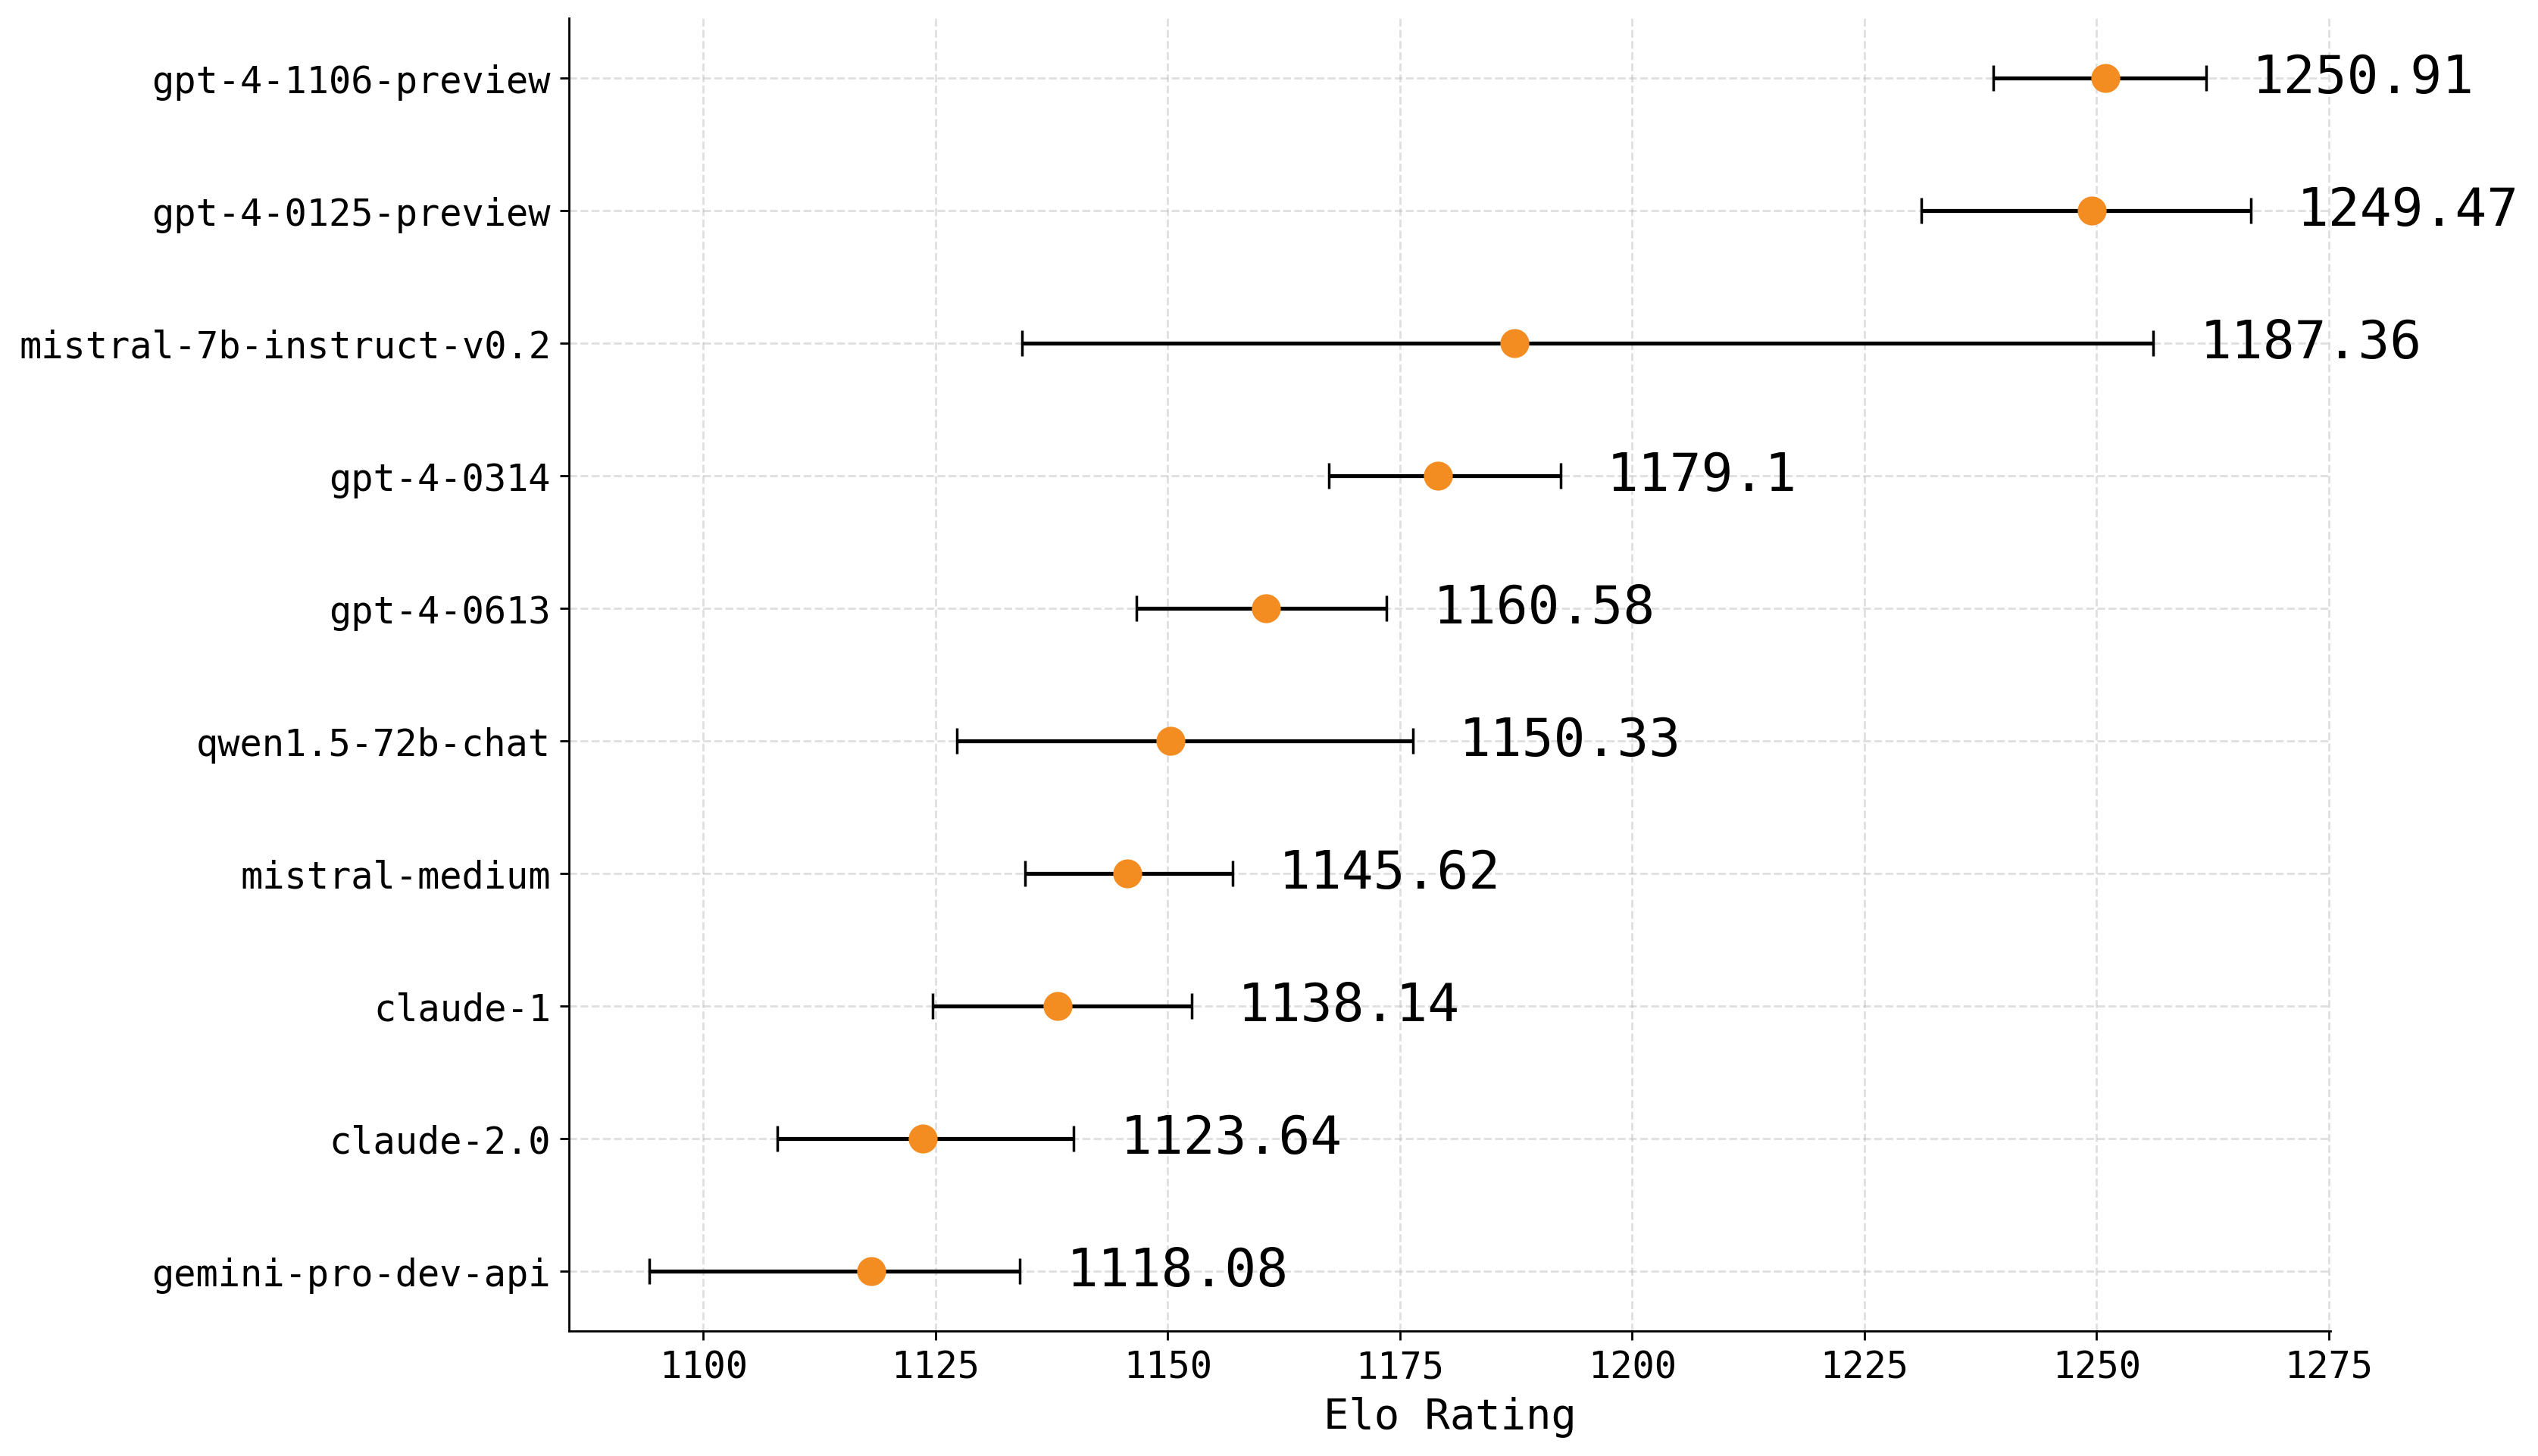

In [117]:
# plot only the top 10 models.
plot_elo_confidence_intervals(ci_df_dropped.head(10), title="Top 10 Elo Ratings (Upon Removing 29/57477 (0.05%) of Preferences)")

In [118]:
df.shape

(57477, 10)

In [119]:
29/57477

0.0005045496459453346

In [120]:
# Get sorted items and find index of vicuna-13b
sorted_items = sorted(bt_scores_with_names.items(), key=lambda x: x[1], reverse=True)
vicuna_idx = next(i for i, (k,v) in enumerate(sorted_items) if k == 'stripedhyena-nous-7b')
print(f"vicuna-13b is ranked #{vicuna_idx+1} out of {len(sorted_items)} models")
bt_scores_with_names['stripedhyena-nous-7b']

vicuna-13b is ranked #45 out of 64 models


-0.5365899196852134

#### Run Top-k Robustness Check.

In [163]:
import importlib
from package.RankAMIP import logistic, plot_util

importlib.reload(logistic)
from package.RankAMIP.logistic import LogisticAMIP, isRankingRobust

In [167]:
X.shape, y.shape

((114954, 63), (114954,))

In [ ]:
ks = [1]
results = {}
for k in ks:
    alphaN = 1
    chatbotA = -1 # initialized to indicate robustness.
    while chatbotA == -1:
        chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatNewBetaDiffAMIP, chatIndices = isRankingRobust(k, alphaN, X, y, method = "IF", weighted = True)
        results[(k, alphaN)] = (chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatNewBetaDiffAMIP, chatIndices)
        alphaN += 1

In [ ]:
results_nonrobust_1 = {k: v for k, v in results.items() if v[0] != -1}
results_nonrobust_1

{(1, 2): (0,
  21,
  0.0037864322405765094,
  -0.002731870244861323,
  -0.0023924485273588755,
  array([46592,  7775]))}

In [ ]:
ks = [5, 10, 20]
results2 = {}
for k in ks:
    alphaN = 1
    chatbotA = -1
    while chatbotA == -1:
        chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatIndices = isRankingRobust(k, alphaN, X, y, weighted = True)
        results2[(k, alphaN)] = (chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatIndices)
        alphaN += 1

In [ ]:
results_nonrobust_2 = {k: v for k, v in results2.items() if v[0] != -1}
results_nonrobust_2

{(5, 3): (41,
  47,
  0.01376073850843107,
  -0.001148770551445799,
  array([20425, 38755, 13835])),
 (10, 1): (5,
  4,
  0.0008246616768733395,
  -0.0012153237089130853,
  array([24811])),
 (20, 1): (35,
  48,
  0.007468269893045054,
  -0.0006298890499366605,
  array([5389]))}

In [ ]:
# combine results_nonrobust_1 and results_nonrobust_2.
results_nonrobust = {**results_nonrobust_1, **results_nonrobust_2}
results_nonrobust
# save results as a .pkl file.
# import pickle
# with open('results/ChatbotArenaNonrobustWtd.pkl', 'wb') as f:
#     pickle.dump(results_nonrobust, f)

In [ ]:
results_nonrobust

{(1, 2): (21,
  None,
  -0.004146461884523535,
  0.002200252892290602,
  array([46259,  6212])),
 (3, 29): (6,
  61,
  0.7214777505716051,
  -0.026849342132582388,
  array([26551, 17137, 40808, 32585,  3046, 11617, 39409, 39779, 33011,
         56011, 24859, 28859, 48893, 17324, 38734, 13179, 18149, 34968,
         37289, 20538,  1308,  5210, 23104, 49522,  7020, 46358, 27533,
         48536, 40704])),
 (5, 3): (41,
  47,
  0.01376073850843107,
  -0.001148770551445799,
  array([20425, 38755, 13835])),
 (10, 1): (5,
  4,
  0.0008246616768733395,
  -0.0012153237089130853,
  array([24811])),
 (20, 1): (35,
  48,
  0.007468269893045054,
  -0.0006298890499366605,
  array([5389]))}

Plot arena BT-scores.

In [ ]:
rankings = return_rankings_list(X, y, results, 1, 2, player_to_id)

In [ ]:
def plot_bt_scores(X, y, rankings, alphaN, topk, plot_title, filename_to_save):
    """
    Plots BT scores before and after data removal.
    
    Args:
    X: np.ndarray, the design matrix.
    y: np.ndarray, the response variable.
    rankings: list of tuples, (model_name, full_score, old_score, new_score)
    alphaN: int, number of dropped matches
    topk: int, number of top models to display
    plot_title: str, title of the plot
    filename_to_save: str, path to save the figure
    """
    # Extract top-k entries
    # Sorted by old_scores (index 2) in descending.
    rankings = sorted(rankings[:topk], key=lambda x: x[2], reverse=False)
    model_names = [x[0] for x in rankings[:topk]]
    old_scores = [x[2] for x in rankings[:topk]]
    new_scores = [x[3] for x in rankings[:topk]]
    num_matches_total = len(y)
    y_plot = np.arange(len(rankings[:topk]))
    offset = 0.15
    # Plot.
    # Set global font to monospace and increase default font size
    plt.rcParams.update({
        'font.family': 'monospace',
        'font.size': 14
    })

    # Plot
    plt.figure(figsize=(14, 7), dpi=350)

    # Scatter
    plt.scatter(old_scores, y_plot, marker='o', color='#e97442', s=96) # label='BT Score Full Data',
    # plt.scatter(new_scores, y_plot + offset, 
    #             label=f'BT Score After Dropping {alphaN} out of {num_matches_total}\n matches ({(alphaN/num_matches_total * 100):.3f}%)',
    #             marker='s', color='orange', s=72)

    # Extend x-axis limits slightly to the left and right
    min_score = min(old_scores)
    max_score = max(old_scores) # max(max(old_scores), max(new_scores))
    plt.xlim(min_score - 0.05, max_score + 0.05)

    # Annotate scores next to points
    for i in range(len(y_plot)):
        if i > len(y_plot) - 3:
            # Position the text to the left of the point
            plt.text(old_scores[i] - 0.03, y_plot[i], f'{old_scores[i]:.3f}', 
                    va='center', ha='right', fontsize=21, fontfamily='monospace', color='#e97442')
        else:
            # Position the text to the right of the point
            plt.text(old_scores[i] + 0.03, y_plot[i], f'{old_scores[i]:.3f}', 
                    va='center', ha='left', fontsize=21, fontfamily='monospace', color='#e97442')

    # Axis
    plt.xlabel('Bradley-Terry Score', fontsize=22, fontfamily='monospace')
    plt.yticks(y_plot, model_names, fontsize=18, fontfamily='monospace')
    plt.xticks(fontsize=18, fontfamily='monospace')
    # plt.title(plot_title, fontsize=22, fontfamily='monospace')
    # plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()

    # Remove top and right spines
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    # Save
    plt.savefig(filename_to_save, bbox_inches='tight')
    plt.close()

In [ ]:
# plot top-20 models on full chatbot arena.
filename_to_save = 'fig/top10_cba.png'
plot_title = 'Model Rankings in Chatbot Arena'
plot_bt_scores(X, y, rankings, alphaN, 10, plot_title, filename_to_save)

#### Below, we inspect the ranking flip between the first- and second-place models.

In [ ]:
### Load in results.
import pickle
with open("results/ChatbotArenaNonrobustWtd.pkl", "rb") as f:
    chatBotArenaDataDropped = pickle.load(f)

In [ ]:
chatBotArena_noTies = pd.read_csv("data/chatBotArena_noTies.csv")
chatBotArena_noTies.head()

,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain...","[""The question of whether it is morally right ...","[""As an AI, I don't have personal beliefs or o...",1,0,0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage lice...","[""A marriage license is a legal document that ...","[""A marriage license and a marriage certificat...",0,1,0
2,96401,llama-2-13b-chat,mistral-7b-instruct,"[""How can I create a test set for a very rare ...","[""Creating a test set for a very rare category...","[""When building a classifier for a very rare c...",1,0,0
3,198779,koala-13b,gpt-3.5-turbo-0314,"[""What is the best way to travel from Tel-Aviv...","[""The best way to travel from Tel Aviv to Jeru...","[""The best way to travel from Tel-Aviv to Jeru...",0,1,0
4,292873,vicuna-13b,gpt-4-0314,"[""Construct a rap battle, in the style of Epic...","[""[Zeus]\nYo, it's the king of the gods on the...","[""(Verse 1 - Zeus)\n\nI'm the king of the gods...",0,1,0


9 evals were dropped to flip model i.d. 16 and i.d. None (the reference model).

The name of these models are: 
('gpt-4-0125-preview', 0: 'gpt-4-1106-preview')

In [ ]:
## Count number of games between the two models that changed ranks.
is_gpt41106_gpt40125 = (
    (chatBotArena_noTies['model_a'].str.contains('gpt-4-0125-preview') & chatBotArena_noTies['model_b'].str.contains('gpt-4-1106-preview')) |
    (chatBotArena_noTies['model_a'].str.contains('gpt-4-1106-preview') & chatBotArena_noTies['model_b'].str.contains('gpt-4-0125-preview'))
)

num_gpt41106_gpt40125 = chatBotArena_noTies[is_gpt41106_gpt40125].shape[0]
print("Number of games between GPT-4-1106 and GPT-4-0125: ", num_gpt41106_gpt40125)

Number of games between GPT-4-1106 and GPT-4-0125:  67


In [ ]:
# model pairs (sorted to group symmetric pairs)
chatBotArena_noTies['model_pair'] = chatBotArena_noTies.apply(lambda row: tuple(sorted([row['model_a'], row['model_b']])), axis=1)
chatBotArena_noTies['model_pair']

0                (gpt-4-0613, gpt-4-1106-preview)
1                         (gpt-4-0613, koala-13b)
2         (llama-2-13b-chat, mistral-7b-instruct)
3                 (gpt-3.5-turbo-0314, koala-13b)
4                        (gpt-4-0314, vicuna-13b)
                           ...                   
39711                      (claude-1, gpt-4-0613)
39712              (claude-2.0, llama-2-13b-chat)
39713                      (alpaca-13b, claude-1)
39714                    (palm-2, tulu-2-dpo-70b)
39715    (gemini-pro-dev-api, gpt-4-1106-preview)
Name: model_pair, Length: 39716, dtype: object

In [ ]:
# Count number of games per model pair
pair_counts = chatBotArena_noTies['model_pair'].value_counts()

# Compute average
average_games_per_pair = pair_counts.mean()
print("Average number of games per model pair:", average_games_per_pair)

Average number of games per model pair: 31.900401606425703


In [ ]:
# Find the win margin between 'gpt-4-0125-preview' and 'gpt-4-1106-preview'
# that is, find all games that are between the two models.
dfFlippedRanking = chatBotArena_noTies[is_gpt41106_gpt40125]
## Count number of games between that 'gpt-4-0125-preview' won.
gpt40125_wins = (
    (dfFlippedRanking['model_a'].str.contains('gpt-4-0125-preview') & dfFlippedRanking['winner_model_a'] == 1) |
    (dfFlippedRanking['model_b'].str.contains('gpt-4-0125-preview') & dfFlippedRanking['winner_model_b'] == 1)
)
num_gpt40125_wins = dfFlippedRanking[gpt40125_wins].shape[0]
print("Proportion of games that GPT-4-0125 won: ", num_gpt40125_wins / num_gpt41106_gpt40125)

Proportion of games that GPT-4-0125 won:  0.5373134328358209


#### Player involvement in dropped matches

In [ ]:
chatBotArenaDataDropped

{(1, 9): (16,
  None,
  0.03365783604990017,
  -0.0012388871146928558,
  array([ 2370,  3227, 38242, 10155, 11353, 17714, 18638, 19742, 32828])),
 (3, 24): (6,
  30,
  0.2132132330351283,
  -0.007985048942084516,
  array([24342, 29361, 38576, 36203, 12188, 15215,  3643, 36863, 27987,
          2443, 14012, 12035, 17662,  9137,  4812, 15290, 15514, 27250,
         36462,   469, 32825,  7193, 27463, 34265])),
 (5, 5): (30,
  38,
  0.03657306106365754,
  -0.00615664236957858,
  array([ 9754, 19106, 20511,  9565, 26870])),
 (10, 3): (39,
  4,
  0.011066418306820314,
  -0.0020685804166893362,
  array([16514,   601,  7082])),
 (20, 2): (56,
  19,
  0.015632264920975247,
  -0.01379039709834684,
  array([ 2783, 22323]))}

In [ ]:
# Filter out rows where either model_a or model_b is one of the specified models
exclude_models = ['gpt-4-0125-preview', 'gpt-4-1106-preview']

not_gpt_previews = ~(
    chatBotArena_noTies['model_a'].isin(exclude_models) |
    chatBotArena_noTies['model_b'].isin(exclude_models)
)

chatBotArena_nogpt = chatBotArena_noTies[not_gpt_previews]

In [ ]:
chatBotArena_nogpt.shape[0] # run the top-1 procedure on the filtered data.

33625

In [ ]:
chatBotArena_nogpt

,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage lice...","[""A marriage license is a legal document that ...","[""A marriage license and a marriage certificat...",0,1,0
2,96401,llama-2-13b-chat,mistral-7b-instruct,"[""How can I create a test set for a very rare ...","[""Creating a test set for a very rare category...","[""When building a classifier for a very rare c...",1,0,0
3,198779,koala-13b,gpt-3.5-turbo-0314,"[""What is the best way to travel from Tel-Aviv...","[""The best way to travel from Tel Aviv to Jeru...","[""The best way to travel from Tel-Aviv to Jeru...",0,1,0
4,292873,vicuna-13b,gpt-4-0314,"[""Construct a rap battle, in the style of Epic...","[""[Zeus]\nYo, it's the king of the gods on the...","[""(Verse 1 - Zeus)\n\nI'm the king of the gods...",0,1,0
5,313413,mixtral-8x7b-instruct-v0.1,vicuna-13b,"[""Why water is not used in bath tub?""]","[""Water is actually used in a bath tub. A bath...","[""Water is not used in a bath tub because it i...",1,0,0
...,...,...,...,...,...,...,...,...,...
39710,4294633312,pplx-7b-online,gpt-4-0613,"[""abc""]","[""It seems like you're referring to the Califo...","[""Hello! It seems like you've typed \""abc.\"" H...",1,0,0
39711,4294656694,gpt-4-0613,claude-1,"[""A simple mnemonic for \u03c0:\n\""How I wish ...","[""Sure, let's break it down:\n\n1. \""How\"" has...","[""Here is how that mnemonic represents the dig...",1,0,0
39712,4294692063,claude-2.0,llama-2-13b-chat,"[""In python, implement a naive Bayes with gaus...","[""Here is an implementation of a naive Bayes c...","[""Sure! Here's an implementation of a naive Ba...",1,0,0
39713,4294710549,claude-1,alpaca-13b,"[""is it unethical to work on building weapons?...","[""Working on weapons technology raises some et...","[""It depends on the context. Weapons can be us...",1,0,0


In [ ]:
results_wout_gpt_preview = {}
k = 1
alphaN = 1
chatbotA = -1
while chatbotA == -1:
    chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatIndices = isRankingRobust(k, alphaN, X, y)
    results_wout_gpt_preview[(k, alphaN)] = (chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatIndices)
    alphaN += 1

#### Player involvement w out in-question matches

In [ ]:
# make design matrix for BT.
rawBT_chatBotArena_nogpt = chatBotArena_nogpt[['model_a', 'model_b', 'winner_model_a']]

newX, newy, player_to_id = make_BT_design_matrix(rawBT_chatBotArena_nogpt)
newX.shape, newy.shape

((33625, 61), (33625,))

In [ ]:
# run logistic regression on X, y
gpt_AMIP = LogisticAMIP(newX, newy, fit_intercept=False, penalty=None)

In [ ]:
# compare the two GPT-preview models.
model_1 = 16
model_2 = None
alphaN = 1
sign_change_refit = False
while sign_change_refit == False: # increment alphaN until we find a sign change.
        print("testing alphaN: ", alphaN)
        sign_change_amip, sign_change_refit, original_beta_diff, new_beta_diff_amip, new_beta_diff_refit, indices = LogisticAMIP.AMIP_sign_change(gpt_AMIP, alphaN, model_1, model_2, 
                         method = "1sN", refit = True)
        alphaN += 1

testing alphaN:  1
testing alphaN:  2
testing alphaN:  3
testing alphaN:  4
testing alphaN:  5
testing alphaN:  6
testing alphaN:  7
testing alphaN:  8
testing alphaN:  9
testing alphaN:  10
testing alphaN:  11
testing alphaN:  12
testing alphaN:  13
testing alphaN:  14
testing alphaN:  15
testing alphaN:  16
testing alphaN:  17
testing alphaN:  18
testing alphaN:  19
testing alphaN:  20
testing alphaN:  21
testing alphaN:  22
testing alphaN:  23
testing alphaN:  24
testing alphaN:  25
testing alphaN:  26
testing alphaN:  27
testing alphaN:  28
testing alphaN:  29
testing alphaN:  30
testing alphaN:  31
testing alphaN:  32
testing alphaN:  33
testing alphaN:  34
testing alphaN:  35
testing alphaN:  36
testing alphaN:  37
testing alphaN:  38
testing alphaN:  39
testing alphaN:  40
testing alphaN:  41
testing alphaN:  42
testing alphaN:  43
testing alphaN:  44
testing alphaN:  45
testing alphaN:  46
testing alphaN:  47
testing alphaN:  48
testing alphaN:  49
testing alphaN:  50
testing a

In [ ]:
sign_change_amip, sign_change_refit, original_beta_diff, new_beta_diff_amip, new_beta_diff_refit, indices
print("it takes ", alphaN, " iterations w/out the specified models to find a sign change.")

it takes  229  iterations w/out the specified models to find a sign change.


### Manuel check (for each k) on the MIS! 

In [ ]:
results_nonrobust = chatBotArenaDataDropped

In [ ]:
old_tuple = chatBotArenaDataDropped[(1, 2)] # = 0 # change none to -1 (gpt-4-1106-preview).
new_tuple = tuple(-1 if i == 1 and val is None else val for i, val in enumerate(old_tuple))
results_nonrobust[(1, 2)] = new_tuple

In [ ]:
rows = []
for (k, aN), (playerA, playerB, original_beta_diff, new_beta_diff_refit, indices) in results_nonrobust.items():
    rows.append({
        "k-aN": (k, aN),
        "playerA": playerA + 1, # to account for the reference index.
        "playerB": playerB + 1,
        "original_beta_diff": original_beta_diff,
        "new_beta_diff_refit": new_beta_diff_refit,
        "indices": indices
    })
cba_results = pd.DataFrame(rows)
cba_results.head()

,k-aN,playerA,playerB,original_beta_diff,new_beta_diff_refit,indices
0,"(1, 2)",22,0,-0.004146,0.002200,"[46259, 6212]"
1,"(3, 29)",7,62,0.721478,-0.026849,"[26551, 17137, 40808, 32585, 3046, 11617, 3940..."
2,"(5, 3)",42,48,0.013761,-0.001149,"[20425, 38755, 13835]"
3,"(10, 1)",6,5,0.000825,-0.001215,[24811]
4,"(20, 1)",36,49,0.007468,-0.000630,[5389]


In [ ]:
cba_results['indices'][0]

array([46259,  6212])

In [ ]:
# reverse the mapping.
id_to_player = {v: k for k, v in player_to_id.items()}

In [ ]:
id_to_player[24]

'gpt-3.5-turbo-1106'

In [ ]:
# read in the results.
cba_results.head()
cba_results['playerA_Name'] = cba_results['playerA'].map(id_to_player)
cba_results['playerB_Name'] = cba_results['playerB'].map(id_to_player)

In [ ]:
cba_results.head()

,k-aN,playerA,playerB,original_beta_diff,new_beta_diff_refit,indices
0,"(1, 2)",22,0,-0.004146,0.002200,"[46259, 6212]"
1,"(3, 29)",7,62,0.721478,-0.026849,"[26551, 17137, 40808, 32585, 3046, 11617, 3940..."
2,"(5, 3)",42,48,0.013761,-0.001149,"[20425, 38755, 13835]"
3,"(10, 1)",6,5,0.000825,-0.001215,[24811]
4,"(20, 1)",36,49,0.007468,-0.000630,[5389]


In [ ]:
# for each index, find the corresponding row in the original dataframe.
indices = [2783, 22323]  # [9754, 19106, 20511, 9565, 26870]  # [16514, 601, 7082] # [149, 4412] 
chatBotArena_noTies.iloc[indices]
# find the proportion of games where neither 

,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie,model_pair
2783,301329900,gpt-4-1106-preview,nous-hermes-2-mixtral-8x7b-dpo,"[""Your task is to perform relation and entity ...","[""GutMicrobiota(x) \u2227 GoodHealth(y) \u2192...","[""Extraction 1:\n\nGutMicrobiota(x) \u2227 Goo...",0,1,0,"(gpt-4-1106-preview, nous-hermes-2-mixtral-8x7..."
22323,2387156917,gpt-4-1106-preview,nous-hermes-2-mixtral-8x7b-dpo,"[""In a context of plant encyclopedia where we ...","[""1. **Unusual Foliage Coloration**: The White...","[""1. White Firs (Abies concolor) are native to...",0,1,0,"(gpt-4-1106-preview, nous-hermes-2-mixtral-8x7..."


In [ ]:
# k=1. 9 games were dropped to flip models gpt-4-0125-preview (1st place) with gpt-4-1106-preview (2nd place). 
# all dropped matches were between these two models, with gpt-4-0125-preview winning.
# k=3. 24 games were dropped to flip models gpt-4-0314(2nd place) with qwen1.5-72b-chat (5th place).
# all games were between qwen1.5-72b-chat and various other models, qwen1.5-72b-chat loses all of these matches.
# k=5. 5 games were dropped to flip models qwen1.5-72b-chat (5th place) with mistral-medium (6th place).
# all dropped matches were between gpt-4-1106-preview (2nd place) and qwen1.5-72b-chat, with qwen1.5-72b-chat (5th place) winning.
# k=10. 3 games were dropped to flip models yi-34b-chat (10th) and gemini-pro (11th place).
# all dropped matches are between yi-34b-chat and gemini-pro, with yi-34b-chat winning.
# k=20. 2 games were dropped to flip models nous-hermes-2-mixtral-8x7b-dpo (20th place) and 'vicuna-33b'(21st place).
# all dropped matches are between gpt-4-1106-preview (2nd place) and nous-hermes-2-mixtral-8x7b-dpo, with nous-hermes-2-mixtral-8x7b-dpo winning.

# (namely, vicuna-33b, qwen1.5-7b-chat, tulu-2-dpo-70b, gpt-3.5-turbo-1106, llama-2-13b-chat, )

### Inspect the dropped human evals.

In [ ]:
chatbot_arena_results_with_props = add_match_proportions(cba_results, chatBotArena_noTies)
chatbot_arena_results_with_props.head()

In the rank-flipping between mistral and qwen, a total of 5 evaluations where qwen played and won against gpt-4-1106-preview was enough to move its ranking to above that of mistral.

In [ ]:
df.iloc[[46259, 6212]]

,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
46259,3423254003,gpt-4-0613,claude-2.1,"[""You are an expert in linguistics. We saw tha...","[""In Japanese, noun phrases (NPs) can often un...","[""Unfortunately I do not have enough context t...",1,0,0
6212,348668015,vicuna-13b,llama-2-13b-chat,"[""Compose a song about a journey to Mars""]","[""Verse 1:\nWe're leaving Earth behind,\nA jou...","[""(Verse 1)\nI've been dreaming of the red pla...",0,0,1


In [ ]:
matches

NameError: name 'matches' is not defined

In [ ]:
df

In [ ]:
matches = df[df['prompt'].str.contains("name me challenging c++ projects i can add on my cv as a cs student. give me creative ideas and dont forget im a student.", na=False)]
print("\nResponse A:")
print(matches['response_a'].iloc[0])
print("\nResponse B:") 
print(matches['response_b'].iloc[0])

error: multiple repeat at position 22

In [ ]:
# Let's investigate the responses that changed the Top-5 models.
gpt_gpt_inds = cba_results["indices"].iloc[0]
df.iloc[gpt_gpt_inds]

,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
46259,3423254003,gpt-4-0613,claude-2.1,"[""You are an expert in linguistics. We saw tha...","[""In Japanese, noun phrases (NPs) can often un...","[""Unfortunately I do not have enough context t...",1,0,0
6212,348668015,vicuna-13b,llama-2-13b-chat,"[""Compose a song about a journey to Mars""]","[""Verse 1:\nWe're leaving Earth behind,\nA jou...","[""(Verse 1)\nI've been dreaming of the red pla...",0,0,1


In [ ]:
player_to_id

{'gpt-4-1106-preview': 0,
 'koala-13b': 1,
 'llama-2-13b-chat': 2,
 'vicuna-13b': 3,
 'mixtral-8x7b-instruct-v0.1': 4,
 'gemini-pro': 5,
 'gpt-3.5-turbo-0613': 6,
 'gpt-4-0314': 7,
 'vicuna-7b': 8,
 'chatglm3-6b': 9,
 'pplx-70b-online': 10,
 'mpt-30b-chat': 11,
 'llama2-70b-steerlm-chat': 12,
 'claude-1': 13,
 'chatglm-6b': 14,
 'claude-2.0': 15,
 'starling-lm-7b-alpha': 16,
 'gpt-4-0125-preview': 17,
 'llama-2-7b-chat': 18,
 'stablelm-tuned-alpha-7b': 19,
 'vicuna-33b': 20,
 'gpt-4-0613': 21,
 'dolphin-2.2.1-mistral-7b': 22,
 'palm-2': 23,
 'wizardlm-13b': 24,
 'claude-2.1': 25,
 'claude-instant-1': 26,
 'gpt-3.5-turbo-1106': 27,
 'oasst-pythia-12b': 28,
 'qwen-14b-chat': 29,
 'openchat-3.5': 30,
 'qwen1.5-72b-chat': 31,
 'codellama-34b-instruct': 32,
 'deepseek-llm-67b-chat': 33,
 'gpt-3.5-turbo-0125': 34,
 'pplx-7b-online': 35,
 'qwen1.5-4b-chat': 36,
 'fastchat-t5-3b': 37,
 'llama-2-70b-chat': 38,
 'mistral-medium': 39,
 'yi-34b-chat': 40,
 'zephyr-7b-beta': 41,
 'openhermes-2.5-mi

In [ ]:
# MIS: prompts.
# for prompt in chatBotArena_noTies.iloc[gpt4top2_inds]['prompt']:
#     print(prompt)
import textwrap
for i, prompt in enumerate(chatBotArena_noTies.loc[mistral_qwen_inds]['prompt']):
    print(f"\n=== prompt {i+1} ===\n")
    print(textwrap.fill(prompt, width=100))


=== prompt 1 ===

["\nread this content. Do not change the content written. Add 5 more tips in the same tone of voice
and style. \nhave one be use AI \n\nHey freelance writers: Let's talk about writer's block.\n\nI
know, I know. You don't want to say it out loud. It's like \"Voldemort\" or actors saying
\"Macbeth\" out loud (that's why they call it \"The Scottish Play\"). But, like the common cold,
writer's block is out there ... and odds are, it's going to get every freelance writer at some
point.\n\nThe Terror of Writer's Block\n\nYou've probably had it happen to you at one time or
another. You're sitting at your desk, a cup of coffee or cold beverage nearby, ready to start
writing, knocking off those assignments, and adding some zeroes to the bank account. The words are
ready to go ... but somehow, someway, they just won't come out. The blank page remains there,
looking at you, taunting you.\n\nThen the terror starts. \"Oh no,\" you think. \"How long will this
last? Will I get para

In [ ]:
# MIS: Answer ModelA.
# for response_A in chatBotArena_noTies.iloc[gpt4top2_inds]['response_a']:
#     print(response_A)
import textwrap

for i, response_a in enumerate(chatBotArena_noTies.loc[mistral_qwen_inds]['response_a']):
    print(f"\n=== Response {i+1} ===\n")
    print(textwrap.fill(response_a, width=100))


=== Response 1 ===

["6. Use AI Writing Tools\n\nIncorporating AI writing tools can occasionally help break the creative
gridlock. There are various AI assistants that can generate prompts, suggest sentences, or even
complete paragraphs for you. Of course, you'll want to maintain your unique voice and edit AI-
generated content, but it's a useful starting point to overcome writer's block. It can spark new
ideas or simply provide a gentle nudge to get your creative juices flowing.\n\n7. Engage in Physical
Exercise\n\nPhysical activity can help clear your mind and boost your energy levels. Go for a run,
hit the gym, or do a brief workout session. Exercise releases endorphins that can improve your mood
and stimulate your brain, making it easier to overcome writer's block. Plus, you'll feel refreshed
and ready to tackle your writing once you're done.\n\n8. Set Realistic Writing Goals\n\nSometimes,
the pressure of a looming deadline or an overly ambitious goal can contribute to writer's bl

In [ ]:
import textwrap

for i, response_b in enumerate(chatBotArena_noTies.loc[mistral_qwen_inds]['response_b']):
    print(f"\n=== Response {i+1} ===\n")
    print(textwrap.fill(response_b, width=100))


=== Response 1 ===

["6. Use AI to Your Advantage\n\nIn this age of technology, leverage the power of AI to overcome
writer's block. AI writing tools can provide prompts, continue a thought, or even help outline your
piece. It's like having a brainstorming buddy at your fingertips, one who's available 24\/7 and
doesn't mind you bouncing ideas off of them, no matter how rough they might be. Just type in a
sentence or a theme, and let the artificial intelligence give you a nudge in the right direction.
Remember, it's not about replacing your creativity but enhancing it.\n\n7. Set Small, Achievable
Goals\n\nSometimes writer's block stems from feeling overwhelmed by the size of the project. Break
it down into small, manageable pieces. Set a goal for a paragraph, a page, or maybe just a great
opening sentence. Achieving these smaller goals can give you a sense of progress and help build
momentum. As you tick off these mini milestones, the larger project won't seem so daunting.\n\n8.
Engage